refer to: https://leetcode.cn/problems/subsets/solution/hui-su-si-xiang-tuan-mie-pai-lie-zu-he-zi-ji-wen-t/

# 组合 & 排列

In [16]:
nums = [1,2,3,4,5]
k = 3

comb1 = []
def Combination(visited, start, nums, k):
    if len(visited) == k:
        comb1.append(tuple(visited))
        return
    for ii in range(start, len(nums)):
        Combination(visited + [nums[ii]], ii + 1, nums, k)
Combination([], 0, nums, k)

perm1 = []
def Permutation(visited, remaining, k):
    if len(visited) == k:
        perm1.append(tuple(visited))
        return
    for ii in range(len(remaining)):
        Permutation(visited + [remaining[ii]], remaining[0:ii] + remaining[ii+1:], k)
Permutation([], nums, k)

# compare
from itertools import combinations,permutations
comb2 = list(combinations(nums, k))
perm2 = list(permutations(nums, k))

print(comb1.sort() == comb2.sort())
print(perm1.sort() == perm2.sort())

True
True


<span id='P.77'></span>
## [77. 组合](https://leetcode.cn/problems/combinations/)
给定两个整数$n$和$k$，返回范围$[1, n]$中所有可能的$k$个数的组合。

你可以按**任何顺序**返回答案。
[![](https://mermaid.ink/img/pako:eNp1kbsOgjAUhl-FnBkSuXjDxMG4OukkZWhokSbQEiyDIby7balgFLZ-_f6e9vR0kAlCIYZHg-vCuZ0OiDPiJwiSFEHqeUdGAk2-xn8XagrmXaQpnHdrTdHHTTcYuTHoOsGC31ofLvid9WP96ZXG7w1-nf_x_soGxgJTK0PANBPaALhQ0abCjKh_7BB3HASyoBVFEKsloTluS4kA8V5FcSvF9cUziGXTUhfammBJzwyrCVQQ57h8qt0a87sQE1PCpGguw6zMyPo3gUaG3A?type=png)](https://mermaid-js.github.io/mermaid-live-editor/edit#pako:eNp1kbsOgjAUhl-FnBkSuXjDxMG4OukkZWhokSbQEiyDIby7balgFLZ-_f6e9vR0kAlCIYZHg-vCuZ0OiDPiJwiSFEHqeUdGAk2-xn8XagrmXaQpnHdrTdHHTTcYuTHoOsGC31ofLvid9WP96ZXG7w1-nf_x_soGxgJTK0PANBPaALhQ0abCjKh_7BB3HASyoBVFEKsloTluS4kA8V5FcSvF9cUziGXTUhfammBJzwyrCVQQ57h8qt0a87sQE1PCpGguw6zMyPo3gUaG3A)

In [17]:
n = 4
k = 2

record = []
def backtrack(visited, start, k, n):
    if len(visited) == k:
        record.append(visited)
        return
    for ii in range(start, n + 1):
        backtrack(visited + [ii], ii + 1, k, n)
backtrack([], 1, k, n)

print(record)

[[1, 2], [1, 3], [1, 4], [2, 3], [2, 4], [3, 4]]


<span id='P.39'></span>
## [39. 组合总和](https://leetcode.cn/problems/combination-sum/)
$\iff$ <span id='LCR.081'></span> [LCR 081. 组合总和](https://leetcode.cn/problems/Ygoe9J/)<br>
给你一个 **无重复元素** 的整数数组`candidates`和一个目标整数`target`，找出`candidates`中可以使数字和为目标数`target`的所有**不同组合**，并以列表形式返回。你可以按**任意顺序**返回这些组合。<br>
`candidates`中的**同一个**数字可以**无限制重复被选取**。如果至少一个数字的被选数量不同，则两种组合是不同的。

> **组合总和**系列:
> - [39. 组合总和](#P.39): 元素可重复使用
> - [40. 组合总和系列 II](#P.40): 元素只能使用一次, 且需要去重
> - [216. 组合总和 III](#P.216): 标准组合问题, 同[77. 组合](#P.77)
> - [377. 组合总和 Ⅳ](DynamicProgramming.ipynb#P.377): 求数量用dp

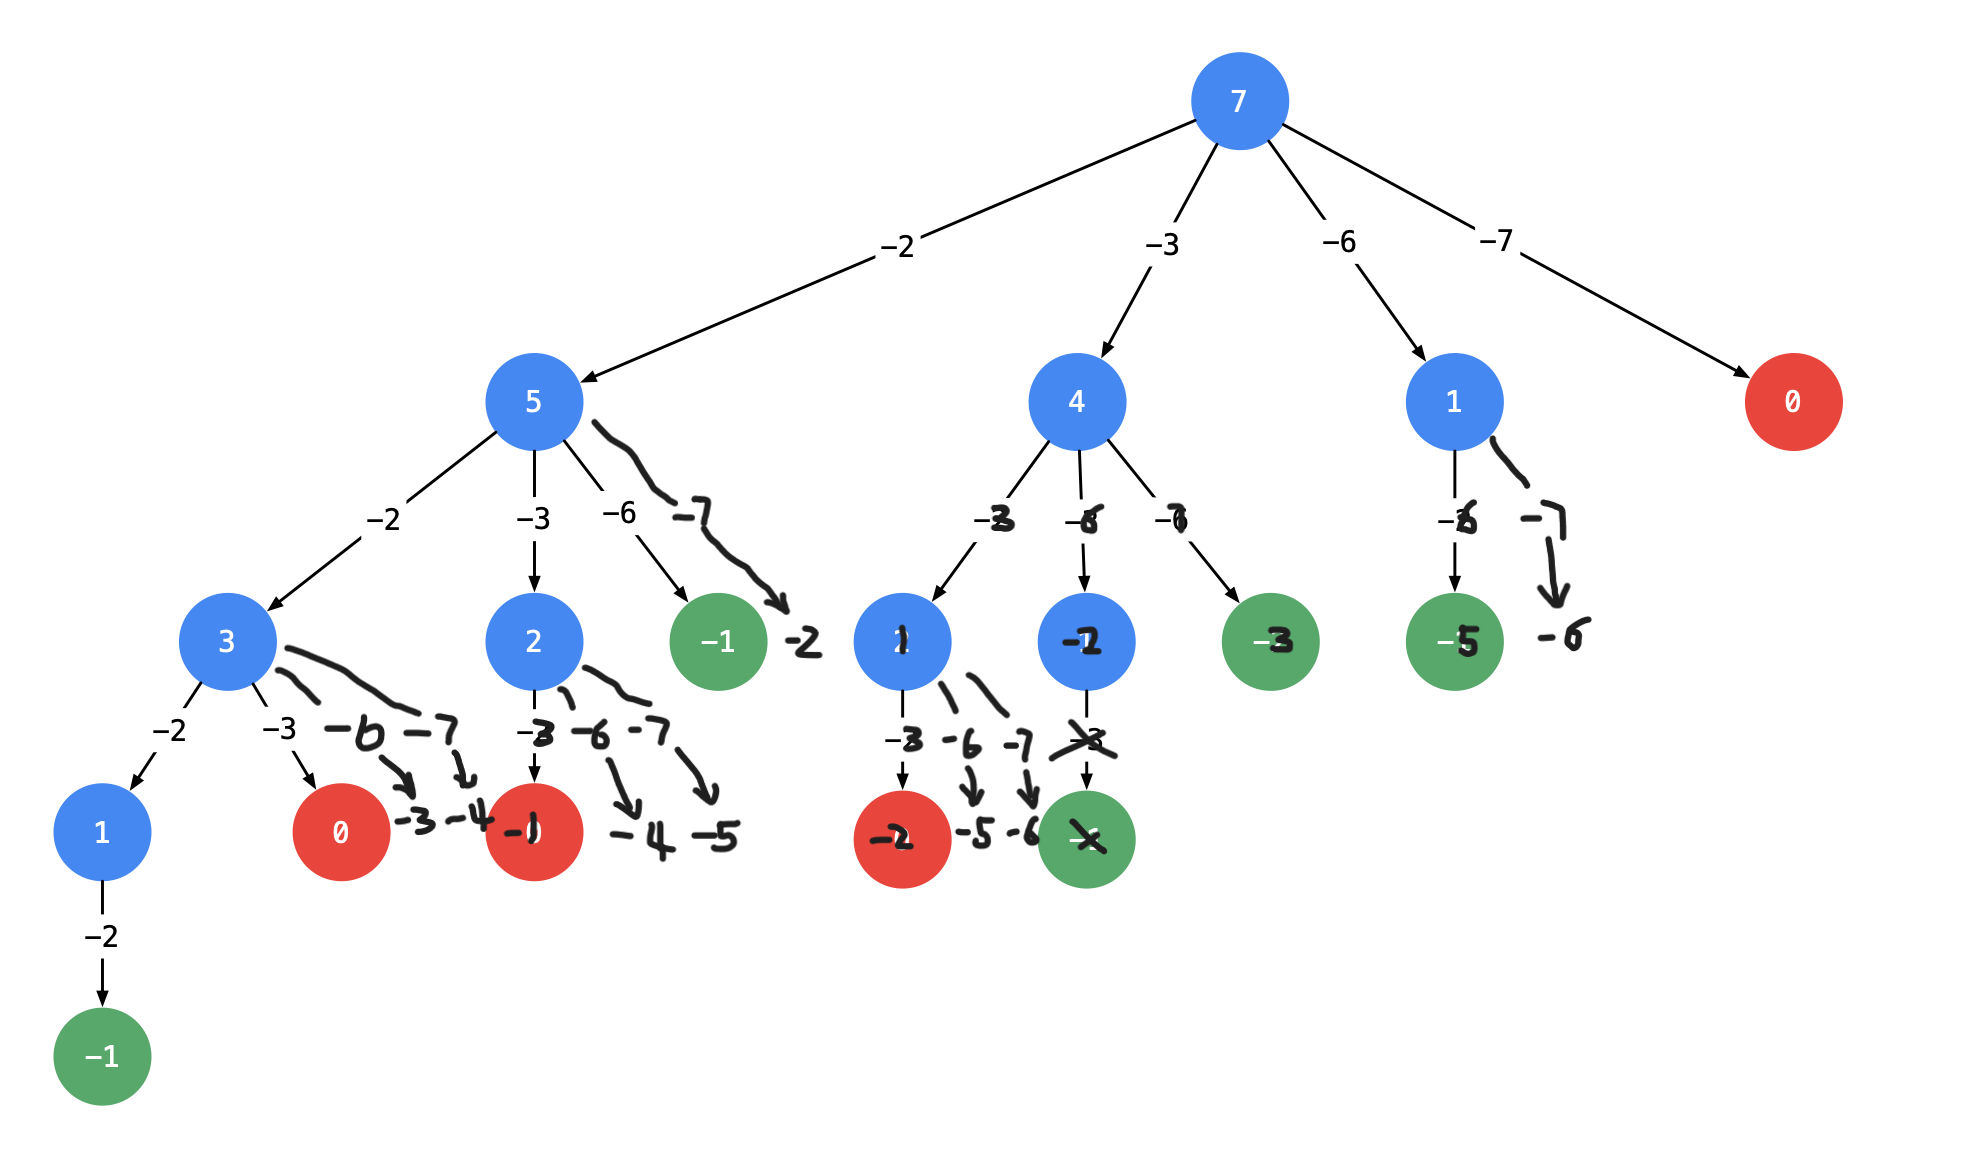

In [18]:
candidates = [2,3,6,7]
target = 7

candidates.sort()
record = []
def backtrack(visited, candidates, start, target):
    for ii in range(start, len(candidates)):
        num = candidates[ii]
        if num > target:
            pass
        elif num == target:
            record.append(visited + [num])
        else:
            backtrack(visited + [num], candidates, ii, target - num) # 可重复
backtrack([], candidates, 0, target)

print(record)

[[2, 2, 3], [7]]


<span id='P.40'></span>
### [40. 组合总和 II](https://leetcode.cn/problems/combination-sum-ii/)
$\iff$ <span id='LCR.082'></span> [LCR 082. 组合总和 II](https://leetcode.cn/problems/4sjJUc/)<br>
给定一个候选人编号的集合`candidates`和一个目标数`target`，找出`candidates`中所有可以使数字和为`target`的组合。<br>
`candidates`中的每个数字在每个组合中只能使用**一次**。<br>
**注意**：解集不能包含重复的组合。 

In [19]:
candidates = [10,1,2,7,6,1,5]
target = 8
# candidates = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
# target = 27

candidates.sort()
record = []
def backtrack(visited, candidates, start, target):
    for ii in range(start, len(candidates)):
        num = candidates[ii]
        if ii > start and candidates[ii - 1] == candidates[ii]:
            continue
        if num > target:
            pass
        elif num == target:
            record.append(visited + [num])
        else:
            backtrack(visited + [num], candidates, ii + 1, target - num) # 不重复
backtrack([], candidates, 0, target)

print(record)

[[1, 1, 6], [1, 2, 5], [1, 7], [2, 6]]


<span id='P.216'></span>
### [216. 组合总和 III](https://leetcode.cn/problems/combination-sum-iii/)
找出所有相加之和为$n$的$k$个数的组合，且满足下列条件：
- 只使用数字1到9
- 每个数字**最多使用一次**

返回 所有可能的有效组合的列表 。该列表不能包含相同的组合两次，组合可以以任何顺序返回。

In [20]:
k = 3
n = 7

record = []
def backtrack(visited, start, k, target):
    if len(visited) == k:
        if target == 0:
            record.append(visited)
        return
    for ii in range(start, 10):
        backtrack(visited + [ii], ii + 1, k, target - ii)
backtrack([], 1, k, n)

print(record)

[[1, 2, 4]]


<span id='P.46'></span>
## [46. 全排列](https://leetcode.cn/problems/permutations/)
给定一个不含重复数字的数组$nums$，返回其所有可能的全排列 。你可以**按任意顺序**返回答案。
[![](https://mermaid.ink/img/pako:eNp1Uj1vwjAQ_SvWzUHCoQKaSh0qVqYygTNYsVMsETtKnaFC_HccO1zsQja_j7t7J98VKiMkFPDT8fZMDl8fTCtBTwxOJYNysfhUIh8QHeCzthpQ_lp7G9DqoU1dvLj2MCP5jL4ZdayfJnl962FG6Iz-PupYP6XxOl16HDX4b6CjARMmkYMHqWhQkjzYkIq6JQsEG1JRt2SPYEMqCp-uE74NqWhqulXwITVWQwaN7BquhLuLK9OEMLBn2UgGhXsKWfP-YhkwfXNW3lvz_acrKGzXywz6VnArd4q7i2qgqPnl17Et10djJiyFsqbbh9vzJ3i7A7xtvKA?type=png)](https://mermaid-js.github.io/mermaid-live-editor/edit#pako:eNp1Uj1vwjAQ_SvWzUHCoQKaSh0qVqYygTNYsVMsETtKnaFC_HccO1zsQja_j7t7J98VKiMkFPDT8fZMDl8fTCtBTwxOJYNysfhUIh8QHeCzthpQ_lp7G9DqoU1dvLj2MCP5jL4ZdayfJnl962FG6Iz-PupYP6XxOl16HDX4b6CjARMmkYMHqWhQkjzYkIq6JQsEG1JRt2SPYEMqCp-uE74NqWhqulXwITVWQwaN7BquhLuLK9OEMLBn2UgGhXsKWfP-YhkwfXNW3lvz_acrKGzXywz6VnArd4q7i2qgqPnl17Et10djJiyFsqbbh9vzJ3i7A7xtvKA)

In [ ]:
nums = [1,2,3]

record = []
def backtrack(visited, remaining):
    if len(remaining) == 0:
        record.append(visited)
    else:
        for ii in range(len(remaining)):
            backtrack(visited + [remaining[ii]], remaining[0:ii] + remaining[ii+1:])
backtrack([], nums)

print(record)

- Exercises  
    - <span id='P.47'></span>[47. 全排列 II](https://leetcode.cn/problems/permutations-ii/)
    - <span id='P.140'></span>[140. 单词拆分 II](https://leetcode.cn/problems/word-break-ii/)

<span id='P.31'></span>
### [31. 下一个排列](https://leetcode.cn/problems/next-permutation/)
整数数组的一个**排列**就是将其所有成员以序列或线性顺序排列。
- 例如，$arr = [1,2,3]$，以下这些都可以视作$arr$的排列：$[1,2,3], [1,3,2], [3,1,2], [2,3,1]$。  

整数数组的**下一个排列**是指其整数的下一个字典序更大的排列。更正式地，如果数组的所有排列根据其字典顺序从小到大排列在一个容器中，那么数组的**下一个排列**就是在这个有序容器中排在它后面的那个排列。如果不存在下一个更大的排列，那么这个数组必须重排为字典序最小的排列（即，其元素按升序排列）。
- 例如，$arr = [1,2,3]$的下一个排列是$[1,3,2]$。  
- 类似地，$arr = [2,3,1]$的下一个排列是$[3,1,2]$。
- 而$arr = [3,2,1]$的下一个排列是$[1,2,3]$，因为$[3,2,1]$不存在一个字典序更大的排列。

给你一个整数数组$nums$，找出$nums$的下一个排列。  
必须**原地**修改，只允许使用额外常数空间。


![SegmentLocal](./fig/31.gif "segment")

1. 首先从后向前查找第一个顺序对$(i,i+1)$，满足$a[i]<a[i+1]$。这样「较小数」即为$a[i]$。此时$[i+1,n)$必然是下降序列。
2. 如果找到了顺序对，那么在区间$[i+1,n)$中从后向前查找第一个元素$j$满足$a[i]<a[j]$。这样「较大数」即为$a[j]$。
3. 交换$a[i]$与$a[j]$，此时可以证明区间$[i+1,n)$必为降序。我们可以直接使用双指针反转区间$[i+1,n)$使其变为升序，而无需对该区间进行排序。

In [ ]:
nums = [1,2,3]

# step 1
i = len(nums) - 2
while i >= 0 and nums[i] >= nums[i + 1]:
    i -= 1
if i >= 0:
    # step 2
    j = len(nums) - 1
    while j >= 0 and nums[i] >= nums[j]:
        j -= 1
    nums[i], nums[j] = nums[j], nums[i]

# step 3
left, right = i + 1, len(nums) - 1
while left < right:
    nums[left], nums[right] = nums[right], nums[left]
    left += 1
    right -= 1

print(nums)

# 子序列/Subsequence
A **subsequence** is a sequence that can be derived from another sequence by deleting some elements without changing the order of the remaining elements.  
**子序列**: 通过删除一些元素（不改变其余元素的顺序）导出的结果/所有可能的组合  
1. [子序列/Subsequence](#子序列/Subsequence) vs [子集/Subset](#子集/Subset):<br>
Subsequence要保证先后顺序; Subset不要求保持先后顺序。<br>排序后的Subset可转化为Subsequence。<br>
2. [子序列/Subsequence](#子序列/Subsequence) vs [子数组/Subarray](#子数组/Subarray):<br>
Subsequence不要求连续, Subarray要求连续。  

In [ ]:
nums = [5,2,3,4,1]

record = []
def backtrack(index, visited):
    if index == len(nums):
        record.append(visited)
    else:
        backtrack(index + 1, visited)
        backtrack(index + 1, visited + [nums[index]])
backtrack(0, [])

record.sort()
for elem in record:
    print(elem)

## todo: [673. 最长递增子序列的个数](https://leetcode-cn.com/problems/number-of-longest-increasing-subsequence/)

In [ ]:
# python
nums = [1,3,5,4,7] # 2
# nums = [2,2,2,2,2] # 5
# nums = [1,2,4,3,5,4,7,2] # 3
dp_maxlen = [1] # 记录以 nums[ii] 结尾的最长上升子序列的长度
dp_count = [1]  # 记录以 nums[ii] 结尾的最长上升子序列的个数

for ii in range(1,len(nums)):
    max_len = 1 # 如果 nums[ii] 都小于或等于之前的元素，则以 nums[ii] 结尾的最长上升子序列的长度为1，数量也为1
    count = 1
    for jj in range(ii):
        if nums[jj] < nums[ii]:
            if dp_maxlen[jj]+1 > max_len:
                max_len = dp_maxlen[jj]+1
                count = dp_count[jj]
            elif dp_maxlen[jj]+1 == max_len:
                count += dp_count[jj]

    dp_maxlen.append(max_len)
    dp_count.append(count)

print(dp_maxlen)
print(dp_count)

max_len = 0
count = 0
for ii in range(len(dp_maxlen)):
    if dp_maxlen[ii] > max_len:
        max_len = dp_maxlen[ii]
        count = dp_count[ii]
    elif dp_maxlen[ii] == max_len:
        count += dp_count[ii]
print(count)

# 子集/Subset
每个位置可选或可不选，或者选择其中一个
<span id='P.78'></span>
## [78. 子集](https://leetcode.cn/problems/subsets/)
$\iff$ <span id='LCR.079'></span>[LCR 079. 子集](https://leetcode.cn/problems/TVdhkn/) <br>
给你一个整数数组`nums`，数组中的元素**互不相同**。返回该数组所有可能的子集（幂集）。<br>
解集**不能**包含重复的子集。你可以按**任意顺序**返回解集。

In [ ]:
nums = [5,2,3,4,1]

nums.sort()
record = []
def backtrack(visited, nums, index):
    if index == len(nums):
        record.append(visited)
    else:
        backtrack(visited, nums, index + 1)
        backtrack(visited + [nums[index]], nums, index + 1)
backtrack([], nums, 0)

record.sort()
for elem in record:
    print(elem)

<span id='P.90'></span>
### [90. 子集 II](https://leetcode.cn/problems/subsets-ii/)
给你一个整数数组`nums`，其中可能包含重复元素，请你返回该数组所有可能的子集(幂集)。<br>
解集**不能**包含重复的子集。返回的解集中，子集可以按**任意顺序**排列。

In [ ]:
nums = [1,2,2]

nums.sort()
record = []
def backtrack(visited, nums, index, label):
    if index == len(nums):
        record.append(visited)
    else:
        if label and index > 0 and nums[index] == nums[index - 1]:
            pass
        else:
            backtrack(visited, nums, index + 1, False)
        backtrack(visited + [nums[index]], nums, index + 1, True)
backtrack([], nums, 0, False)

print(record)

<span id='P.22'></span>
## [22. 括号生成](https://leetcode.cn/problems/generate-parentheses/)
共2n个位置，每个位置由两个选择，即'('或')'

In [ ]:
n = 3

def valid(string):
    count = 0
    for s in string:
        if s == '(':
            count += 1
        else:
            count -= 1
        if count < 0:
            return False
    return count == 0

record = []
def backtrack(visit, n):
    if len(visit) == n:
        if valid(visit):
            record.append(visit)
        return
    backtrack(visit + '(', n)
    backtrack(visit + ')', n)

backtrack("", 2 * n)

print(record)

- Exercises:  
    - <span id='P.17'></span>[17. 电话号码的字母组合](https://leetcode.cn/problems/letter-combinations-of-a-phone-number/)  

<span id='P.37'></span>
### [37. 解数独](https://leetcode.cn/problems/sudoku-solver/)
编写一个程序，通过填充空格来解决数独问题。<br>
数独的解法需**遵循如下规则**：
1. 数字`1-9`在每一行只能出现一次。
2. 数字`1-9`在每一列只能出现一次。
3. 数字`1-9`在每一个以粗实线分隔的`3x3`宫内只能出现一次。（请参考示例图）

数独部分空格内已填入了数字，空白格用`'.'`表示。

**示例 1**：
> **输入**：
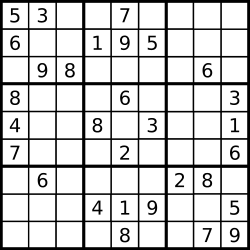
**输出**：
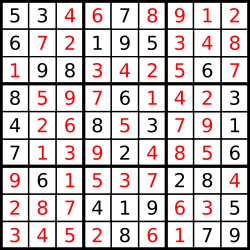


In [3]:
board = [
    ["5","3",".",".","7",".",".",".","."],
    ["6",".",".","1","9","5",".",".","."],
    [".","9","8",".",".",".",".","6","."],
    ["8",".",".",".","6",".",".",".","3"],
    ["4",".",".","8",".","3",".",".","1"],
    ["7",".",".",".","2",".",".",".","6"],
    [".","6",".",".",".",".","2","8","."],
    [".",".",".","4","1","9",".",".","5"],
    [".",".",".",".","8",".",".","7","9"]]

output = []
def backtrack(board, idx_row, idx_col):
    if idx_row == 9:
        output.append([[num for num in row] for row in board])
        return
    if board[idx_row][idx_col] == '.':
        set1 = set([str(ii) for ii in range(1, 10)])
        
        # 从 set1 中删除 idx_row 行出现的数字
        for jj in range(9):
            temp = board[idx_row][jj]
            if temp != '.':
                if temp in set1:
                    set1.remove(temp)
        
        # 从 set1 中删除 idx_col 行出现的数字
        for ii in range(9):
            temp = board[ii][idx_col]
            if temp != '.':
                if temp in set1:
                    set1.remove(temp)
        
        # 从 set1 中删除 block 中出现的数字
        for ii in range(3):
            for jj in range(3):
                temp = board[idx_row // 3 * 3 + ii][idx_col // 3 * 3+ jj]
                if temp != '.':
                    if temp in set1:
                        set1.remove(temp)
        
        # 此时, set1 包含 board[idx_row][idx_col] 可填充的所有候选数字
        for s in set1:
            board[idx_row][idx_col] = s
            if idx_col  < 8:
                backtrack(board, idx_row, idx_col + 1)
            else:
                backtrack(board, idx_row + 1, 0)
            board[idx_row][idx_col] = '.'
    
    # 如果 board[idx_row][idx_col] 为数字, 则往后移动
    else:
        if idx_col  < 8:
            backtrack(board, idx_row, idx_col + 1)
        else:
            backtrack(board, idx_row + 1, 0)

backtrack(board, 0, 0)
for ii in range(len(board)):
    for jj in range(len(board[0])):
        board[ii][jj] = output[0][ii][jj]
for row in board:
    print(row)

['5', '3', '4', '6', '7', '8', '9', '1', '2']
['6', '7', '2', '1', '9', '5', '3', '4', '8']
['1', '9', '8', '3', '4', '2', '5', '6', '7']
['8', '5', '9', '7', '6', '1', '4', '2', '3']
['4', '2', '6', '8', '5', '3', '7', '9', '1']
['7', '1', '3', '9', '2', '4', '8', '5', '6']
['9', '6', '1', '5', '3', '7', '2', '8', '4']
['2', '8', '7', '4', '1', '9', '6', '3', '5']
['3', '4', '5', '2', '8', '6', '1', '7', '9']


<span id='P.93'></span>
## [93. 复原 IP 地址](https://leetcode.cn/problems/restore-ip-addresses/)
**有效IP地址**正好由四个整数（每个整数位于$0$到$255$之间组成，且不能含有前导$0$），整数之间用'.'分隔。
- 例如：$"0.1.2.201"$和$"192.168.1.1"$是**有效**IP地址，但是$"0.011.255.245", "192.168.1.312", "192.168@1.1"$是**无效**IP地址。

给定一个只包含数字的字符串$s$，用以表示一个IP地址，返回所有可能的**有效IP地址**，这些地址可以通过在$s$中插入'.'来形成。你**不能**重新排序或删除$s$中的任何数字。你可以按**任何**顺序返回答案。

In [ ]:
s = "101023"

record = []
def backtrack(visited, remaining):
    if len(remaining) == 0 or len(visited) == 4:
        if len(remaining) == 0 and len(visited) == 4:
            record.append('.'.join(visited))
        return
    else:
        if len(remaining) > 0 and 0 <= int(remaining[0]) < 256:
            backtrack(visited+[remaining[0]], remaining[1:])
        if len(remaining) > 1 and remaining[0] != '0' and 0 <= int(remaining[0:2]) < 256:
            backtrack(visited+[remaining[0:2]], remaining[2:])
        if len(remaining) > 2 and remaining[0] != '0' and 0 <= int(remaining[0:3]) < 256:
            backtrack(visited+[remaining[0:3]], remaining[3:])
backtrack([], s)

print(record)

# 子数组/Subarray
A **subarray** is a slice from a contiguous array (i.e., occupy consecutive positions) and inherently maintains the order of elements.  
连续数组的切片  
Substring与Subarray仅对象不同，遍历相同  

In [ ]:
nums = [5,2,3,4,1]

record = []
for ii in range(len(nums)):
    for jj in range(ii, len(nums)):
        record.append(nums[ii:jj+1])

for elem in record:
    print(elem)

# ["二叉树"根节点 to 叶子节点](TreeNode.ipynb#根节点-to-叶子节点)

<span id='P.50'></span>
# [50. Pow(x, n)](https://leetcode.cn/problems/powx-n/)
实现[pow(x, n)](https://cplusplus.com/reference/valarray/pow/)，即计算`x`的整数`n`次幂函数(即，$x^n$)。

> **题解**: **快速幂** + 递归<br>
如果我们要计算$x^{77}$，我们可以按照：
$$x \to x^2 \to x^4 \to x^9 \to x^{19} \to x^{38} \to x^{77}$$

In [2]:
x = 2.00000 # base
n = 10

def quickMul(N):
    if N ==0:
        return 1.0
    val = quickMul(N // 2)
    if N % 2 == 0:
        return val * val
    else:
        return val * val * x

print( quickMul(n) if n >= 0 else 1.0 / quickMul(-n) )

1024.0


<span id='P.29'></span>
## [29. 两数相除](https://leetcode.cn/problems/divide-two-integers/)
快速乘

# todo
- [36. 有效的数独](https://leetcode.cn/problems/valid-sudoku/)
- [37. 解数独](https://leetcode.cn/problems/sudoku-solver/)
- [51. N 皇后](https://leetcode.cn/problems/n-queens/)
- [52. N 皇后 II](https://leetcode.cn/problems/n-queens-ii/)